In [ ]:
!pip3 install pandas
!pip3 install numpy

In [ ]:
from os import listdir
from os.path import isfile, join
import numpy as np
import pandas as pd

def extract_features (flow_name, flow):
    flow_features = {}

    if flow_name[0].split('.')[0] == '172':
        flow_features['direction'] = 'uplink'
    else:
        flow_features['direction'] = 'downlink'

    flow_features['num_packets'] = len(flow)
    flow_features['num_bytes'] = flow['ip.len'].sum()
    flow_features['min_packet_size'] = flow['ip.len'].min()
    flow_features['max_packet_size'] = flow['ip.len'].max()
    flow_features['mean_packet_size'] = flow['ip.len'].mean()
    flow_features['std_packet_size'] = flow['ip.len'].std()

    iat = pd.to_datetime(flow['frame.time'].str[:-4]).diff(1).dt.total_seconds().iloc[1:];

    flow_features['min_iat']=iat.min()
    flow_features['max_iat']=iat.max()
    flow_features['mean_iat']=iat.mean()
    flow_features['std_iat']=iat.std()
    flow_features['dur']=iat.sum()

    flow_features['sport']=flow_name[2]
    flow_features['dport']=flow_name[3]

    return flow_features


path = "/content/drive/MyDrive/captures/raw_data/check_data"

dumpfiles = [f for f in listdir(path) if isfile(join(path,f))]

apps = np.unique([f.split('_')[0] for f in dumpfiles ])

print(apps, len(apps), len(dumpfiles))

dataset = pd.DataFrame()

for f in dumpfiles:
  #print(f"Processing file {f}")
  df = pd.read_csv(join(path,f))
  try:
    df_tcp = df[df['ip.proto'] == 6]
    df_flows_tcp = df_tcp.groupby(['ip.src','ip.dst','tcp.srcport','tcp.dstport'])
  except:
    continue

  for flow_name, flow in df_flows_tcp:
    flow_features = extract_features(flow_name, flow)
    flow_features['app'] = f.split('_')[0]
    dataset = pd.concat([dataset, pd.DataFrame([flow_features])], ignore_index=True)

display(dataset)

['abc' 'asahi' 'baidu' 'bbc' 'cnbc' 'cnn' 'dailymail' 'google' 'msn'
 'nbcnews' 'ndtv' 'newscn' 'nhk' 'nypost' 'nytimes' 'polimiit' 'rainewsit'
 'theguardian' 'timesofindia' 'vaticannewsva'] 20 60


,direction,num_packets,num_bytes,min_packet_size,max_packet_size,mean_packet_size,std_packet_size,min_iat,max_iat,mean_iat,std_iat,dur,sport,dport,app
0,downlink,36,288148.0,52.0,60712.0,8004.111111,12510.398666,0.000000,0.153409,0.011548,0.025861,0.404183,443.0,57114.0,asahi
1,uplink,30,2487.0,40.0,569.0,82.900000,97.411091,0.000008,0.175395,0.015367,0.033375,0.445654,57114.0,443.0,asahi
2,uplink,29,2348.0,40.0,569.0,80.965517,98.113812,0.000006,0.085666,0.012167,0.021884,0.340684,45542.0,443.0,abc
3,downlink,36,249812.0,52.0,47232.0,6939.222222,9972.468693,0.000001,0.070208,0.007904,0.013883,0.276640,443.0,45542.0,abc
4,uplink,25,2140.0,40.0,569.0,85.600000,105.206939,0.000005,0.127779,0.022791,0.034850,0.546973,45538.0,443.0,abc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,downlink,79,1135160.0,52.0,64756.0,14369.113924,17764.803446,0.000000,0.555127,0.044693,0.095301,3.486077,443.0,35832.0,timesofindia
147,downlink,11,7188.0,52.0,4096.0,653.454545,1215.685516,0.000000,0.339633,0.046244,0.103988,0.462443,443.0,48476.0,timesofindia
148,uplink,13,1399.0,40.0,569.0,107.615385,143.032361,0.000006,0.312949,0.042422,0.087410,0.509065,48476.0,443.0,timesofindia
149,uplink,48,3344.0,40.0,569.0,69.666667,77.253750,0.000008,0.071543,0.006512,0.012679,0.306053,54620.0,443.0,timesofindia


In [ ]:
dataset.to_csv("dataset.csv", index=False)

Merge uplink and down link

In [ ]:
import pandas as pd

def merge_dataset():
    # Reading CSV file
    df = pd.read_csv('/content/dataset.csv')

    # Create DataFrame
    columns = [
        'num_packets_down', 'num_bytes_down', 'min_packet_size_down', 'max_packet_size_down',
        'mean_packet_size_down', 'std_packet_size_down', 'min_iat_down', 'max_iat_down',
        'mean_iat_down', 'std_iat_down', 'dur_down',
        'num_packets_up', 'num_bytes_up', 'min_packet_size_up', 'max_packet_size_up',
        'mean_packet_size_up', 'std_packet_size_up', 'min_iat_up', 'max_iat_up',
        'mean_iat_up', 'std_iat_up', 'dur_up', 'port_pair', 'app'
    ]
    result_df = pd.DataFrame(columns=columns)

    # Filtering Downstream Traffic Data
    downlink_df = df[df['direction'] == 'downlink']

    # Traverse each line of downstream traffic data
    for _, down_row in downlink_df.iterrows():
        # Get the app, sport, dport
        app = down_row['app']
        down_sport = down_row['sport']
        down_dport = down_row['dport']

        # Try to find matching upstream traffic
        matching_uplink = df[(df['direction'] == 'uplink') &
                             (df['app'] == app) &
                             (df['sport'] == down_dport) &
                             (df['dport'] == down_sport)]

        # If found, merged
        if not matching_uplink.empty:
            up_row = matching_uplink.iloc[0]

            # Create a new row of data
            new_row = {
                # Downstream traffic data
                'num_packets_down': down_row['num_packets'],
                'num_bytes_down': down_row['num_bytes'],
                'min_packet_size_down': down_row['min_packet_size'],
                'max_packet_size_down': down_row['max_packet_size'],
                'mean_packet_size_down': down_row['mean_packet_size'],
                'std_packet_size_down': down_row['std_packet_size'],
                'min_iat_down': down_row['min_iat'],
                'max_iat_down': down_row['max_iat'],
                'mean_iat_down': down_row['mean_iat'],
                'std_iat_down': down_row['std_iat'],
                'dur_down': down_row['dur'],

                # Uplink traffic data
                'num_packets_up': up_row['num_packets'],
                'num_bytes_up': up_row['num_bytes'],
                'min_packet_size_up': up_row['min_packet_size'],
                'max_packet_size_up': up_row['max_packet_size'],
                'mean_packet_size_up': up_row['mean_packet_size'],
                'std_packet_size_up': up_row['std_packet_size'],
                'min_iat_up': up_row['min_iat'],
                'max_iat_up': up_row['max_iat'],
                'mean_iat_up': up_row['mean_iat'],
                'std_iat_up': up_row['std_iat'],
                'dur_up': up_row['dur'],

                # Additional Information
                'port_pair': down_row['dport'],
                'app': app
            }

            # Result DataFrame
            result_df = pd.concat([result_df, pd.DataFrame([new_row])], ignore_index=True)

    # Save to CSV
    result_df.to_csv('dataset_merge.csv', index=False)
    print(f"Processing completed, Generated dataset_merge.csv, Total {len(result_df)} records。")

merge_dataset()

<ipython-input-5-1fc7515947c3>:72: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_df = pd.concat([result_df, pd.DataFrame([new_row])], ignore_index=True)


Processing completed, Generated dataset_merge.csv, Total 75 records。


Filter

In [3]:
def filter_dataset():
    # Read the merged CSV file
    df = pd.read_csv('dataset_merge.csv')

    # Display the number of rows before filtering
    print(f"Number of records before filtering: {len(df)}")

    # Apply filters (If any of the conditions are met, deleted)
    filtered_df = df[
        (df['num_packets_down'] >= 7) &
        (df['num_bytes_down'] >= 10000) &
        (df['num_packets_up'] >= 7) &
        (df['num_bytes_up'] >= 500)
    ]
    # Drop the 'dur_down' and 'dur_up' columns
    filtered_df = filtered_df.drop(['dur_down', 'dur_up'], axis=1)

    # Display the number of filtered rows
    print(f"Number of records after filtering: {len(filtered_df)}")
    print(f"Deleted {len(df) - len(filtered_df)} Records")

    # Save
    filtered_df.to_csv('dataset_filted.csv', index=False)

filter_dataset()

Number of records before filtering: 75
Number of records after filtering: 60
Deleted 15 Records


k=1, Accuracy: 0.7500
k=2, Accuracy: 0.7667
k=3, Accuracy: 0.7833
k=4, Accuracy: 0.7500
k=5, Accuracy: 0.7000
k=6, Accuracy: 0.6833
k=7, Accuracy: 0.7000
k=8, Accuracy: 0.6833
k=9, Accuracy: 0.7000
k=10, Accuracy: 0.6833

The optimal k value is 3，the corresponding accuracy is 0.7833


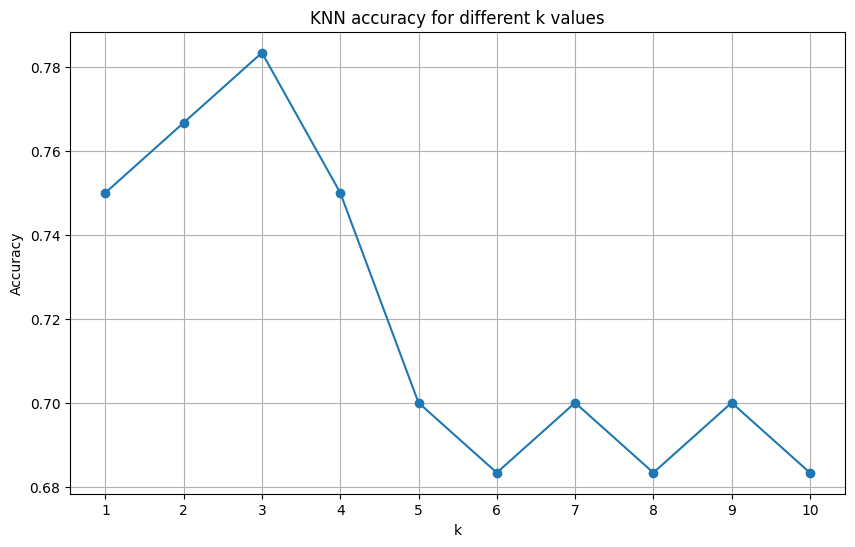

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


# Reading the dataset
dataset = pd.read_csv('/content/dataset_train.csv')

# Data preprocessing
X = dataset.drop(['port_pair'], axis=1).dropna()
APP = X['app']
X = X.drop(['app'], axis=1)

# Divide the training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, APP, test_size=0.3, random_state=36)

# Feature Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Using different k values
k_values = range(1, 11)
accuracies = []

for k in k_values:
    # Create and train a KNN classifier
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    # Make predictions on the test set
    y_pred = knn.predict(X_test_scaled)

    # Calculation accuracy
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

    print(f"k={k}, Accuracy: {accuracy:.4f}")

# Find the best k value
best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)
print(f"\nThe optimal k value is {best_k}，the corresponding accuracy is {best_accuracy:.4f}")

# Visualize the accuracy for different k values
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-')
plt.title('KNN accuracy for different k values')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.savefig('knn_accuracy.png')
plt.show()



Test Results with k=3:
Accuracy: 0.7000


<Figure size 1000x800 with 0 Axes>

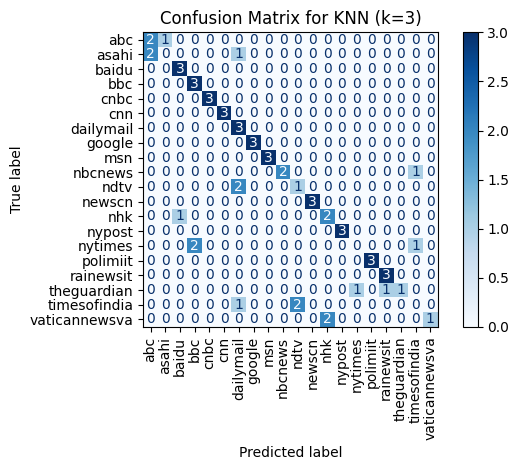

In [5]:
def test_knn_model(best_k, scaler, X_train, y_train, check_data_path):

    # Read the dataset
    check_dataset = pd.read_csv(check_data_path)

    # Process the data
    X_check = check_dataset.drop(['port_pair'], axis=1).dropna()
    y_check = X_check['app']
    X_check = X_check.drop(['app'], axis=1)

    # Ensure X_check has the same columns as X_train
    if set(X_check.columns) != set(X_train.columns):
        raise ValueError(f"Test data columns {X_check.columns} don't match training data columns {X_train.columns}")

    # Reorder columns
    X_check = X_check[X_train.columns]
    X_check_scaled = scaler.transform(X_check)

    # Create and train a KNN classifier with the best k
    knn = KNeighborsClassifier(n_neighbors=best_k)
    knn.fit(X_train_scaled, y_train)
    # Calculate accuracy
    y_pred = knn.predict(X_check_scaled)
    accuracy = accuracy_score(y_check, y_pred)
    # Confusion matrix
    cm = confusion_matrix(y_check, y_pred)
    plt.figure(figsize=(10, 8))

    classes = sorted(y_check.unique())

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=90)
    plt.title(f'Confusion Matrix for KNN (k={best_k})')
    plt.tight_layout()
    plt.savefig('knn_confusion_matrix.png')

    # Create a dataframe with actual and predicted values
    results_df = pd.DataFrame({
        'Actual': y_check,
        'Predicted': y_pred
    })

    # Count occurrences for each app category
    actual_counts = results_df['Actual'].value_counts()
    pred_counts = results_df['Predicted'].value_counts()

    all_apps = sorted(set(actual_counts.index) | set(pred_counts.index))
    actual_counts = actual_counts.reindex(all_apps, fill_value=0)
    pred_counts = pred_counts.reindex(all_apps, fill_value=0)


    return accuracy, cm, knn

# Check data
check_data_path = '/content/dataset_check.csv'

# Test the model
test_accuracy, conf_matrix, best_model = test_knn_model(
    best_k,
    scaler,
    X_train,
    y_train,
    check_data_path
)

# Print detailed results
print(f"\nTest Results with k={best_k}:")
print(f"Accuracy: {test_accuracy:.4f}")

plt.show()